# Attention Alignment Notebook

Goal: Compare **attention behavior** across:
- Centralized model
- FedAvg
- FedProx
- SCAFFOLD

We will answer 4 questions:

1) Do models focus on the same tokens given the same input **and prediction**?
2) Are there cases where models make the same prediction but rely on different tokens?
3) How does attention agreement change across label frequency?
4) Which federated method is closest to centralized in attention structure?

Key principle: **Prediction agreement uses each model’s own per-label thresholds** (computed on validation).


## Set Up

In [1]:
# Imports

from torch.utils.data import DataLoader, TensorDataset
from gensim.models import Word2Vec
import torch
import torch.nn as nn
import torch.nn.functional as F

import numpy as np
import pandas as pd
from tqdm import tqdm
from typing import Optional, Dict, List, Tuple

import os
import math
from collections import Counter

import matplotlib.pyplot as plt
from IPython.display import HTML, display

torch.manual_seed(42)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)


Device: cuda


In [2]:
# Data Loader

def load_data(split: str, batch_size: int = 32, shuffle: bool = False) -> DataLoader:
    X = torch.load(os.path.join("..", "Data", f"X_{split}.pt"))
    Y = torch.load(os.path.join("..", "Data", f"Y_{split}.pt"))
    return DataLoader(
        TensorDataset(X, Y),
        batch_size=batch_size,
        shuffle=shuffle,
        pin_memory=True
    )

In [3]:
# Model Definition

class ConvAttnPool(nn.Module):
    def __init__(
        self,
        table_path: str,
        label_space: int = 50,
        num_of_filters: int = 10,
        kernel_size: int = 3,
        drop_out: float = 0.2
    ):
        super().__init__()
        w2v = Word2Vec.load(table_path)
        vocab_size, embed_d = w2v.wv.vectors.shape

        embed_table = torch.from_numpy(w2v.wv.vectors).float()
        embed_table = torch.cat([embed_table, torch.zeros((1, embed_d))], dim=0)

        self.embed = nn.Embedding.from_pretrained(embeddings=embed_table, padding_idx=vocab_size)
        self.embed_drop = nn.Dropout(p=drop_out)

        self.conv = nn.Conv1d(
            in_channels=embed_d,
            out_channels=num_of_filters,
            kernel_size=kernel_size,
            padding=kernel_size // 2,
        )

        self.U = nn.Linear(num_of_filters, label_space)
        self.final = nn.Linear(num_of_filters, label_space)

        self.embedding_size = embed_d

    def forward(self, x: torch.Tensor) -> Tuple[torch.Tensor, torch.Tensor]:
        x = self.embed(x)                      # (B, L, E)
        x = self.embed_drop(x)
        x = x.transpose(1, 2)                  # (B, E, L)
        x = torch.tanh(self.conv(x).transpose(1, 2))  # (B, L, F)

        alpha = F.softmax(self.U.weight.matmul(x.transpose(1, 2)), dim=2)  # (B, C, L)
        m = alpha.matmul(x)                    # (B, C, F)
        y = self.final.weight.mul(m).sum(dim=2).add(self.final.bias)       # (B, C)
        return y, alpha


def GenerateModel(table_path: str, n_filters: int, window_size: int, label_space: int = 50) -> ConvAttnPool:
    return ConvAttnPool(
        table_path=table_path,
        drop_out=0.2,
        num_of_filters=n_filters,
        kernel_size=window_size,
        label_space=label_space,
    )


In [4]:
# Config + Token Decoder Setup

config = {
    "batch_size": 32,
    "n_filters": 21,
    "window_size": 6,
}

model_param_path = os.path.join("..", "Model", "processed_full.w2v")

# Recover mapping index -> token, plus PAD index convention
w2v = Word2Vec.load(model_param_path)
idx_to_token = w2v.wv.index_to_key
PAD_INDEX = len(idx_to_token)

def decode_sequence(token_ids_1d: torch.Tensor) -> List[str]:
    toks = []
    for idx in token_ids_1d.detach().cpu().tolist():
        if idx == PAD_INDEX:
            toks.append("<PAD>")
        else:
            toks.append(idx_to_token[idx])
    return toks

print("Vocab size:", len(idx_to_token), "| PAD_INDEX:", PAD_INDEX)


Vocab size: 150853 | PAD_INDEX: 150853


In [5]:
# Load Models + Datasets

MODEL_PATHS = {
    "Centralized": "../History/models/central_best_attention.pt",
    "FedAvg":      "../History/models/fedavg_c2e3_best_attention.pt",
    "FedProx":     "../History/models/fedprox_c2e3_best_attention.pt",
    "SCAFFOLD":    "../History/models/scaffold_c2e3_best_attention.pt",
}

def load_model(path: str) -> nn.Module:
    model = GenerateModel(
        table_path=model_param_path,
        n_filters=config["n_filters"],
        window_size=config["window_size"],
    ).to(device)
    state = torch.load(path, map_location=device)
    model.load_state_dict(state)
    model.eval()
    return model

models: Dict[str, nn.Module] = {name: load_model(p) for name, p in MODEL_PATHS.items()}
print("Loaded models:", list(models.keys()))

# Load splits
train_loader = load_data("train", batch_size=config["batch_size"], shuffle=False)
val_loader   = load_data("val",   batch_size=config["batch_size"], shuffle=False)
test_loader  = load_data("test",  batch_size=config["batch_size"], shuffle=False)

# Also keep datasets for random indexing convenience
X_test = torch.load(os.path.join("..", "Data", "X_test.pt"))
Y_test = torch.load(os.path.join("..", "Data", "Y_test.pt"))
test_dataset = TensorDataset(X_test, Y_test)
print("Test samples:", len(test_dataset))


Loaded models: ['Centralized', 'FedAvg', 'FedProx', 'SCAFFOLD']
Test samples: 1729


## Helper Functions

In [6]:
# Recomputer Per-Label Thresholds Per Model

@torch.no_grad()
def find_best_thresholds_per_label(model: nn.Module, data_loader: DataLoader, device: torch.device) -> torch.Tensor:
    """
    Returns thresholds tensor of shape (C,) on CPU.
    Threshold grid: 0.05..0.90 step 0.05 (matches your old notebook logic).
    """
    model.eval()
    all_logits, all_y = [], []
    for Xb, yb in data_loader:
        Xb, yb = Xb.to(device), yb.to(device)
        logits, _ = model(Xb)
        all_logits.append(logits)
        all_y.append(yb)

    logits = torch.cat(all_logits, dim=0)
    y = torch.cat(all_y, dim=0)
    probs = torch.sigmoid(logits)

    C = y.shape[1]
    best_thr = torch.zeros(C, device=device)

    for c in range(C):
        best_f1, best_t = -1.0, 0.3
        y_c = y[:, c].long()
        p_c = probs[:, c]
        for t in torch.arange(0.05, 0.95, 0.05, device=device):
            pred = (p_c >= t).long()
            tp = (pred * y_c).sum().item()
            fp = (pred * (1 - y_c)).sum().item()
            fn = ((1 - pred) * y_c).sum().item()
            prec = tp / (tp + fp + 1e-9)
            rec  = tp / (tp + fn + 1e-9)
            f1   = 2 * prec * rec / (prec + rec + 1e-9)
            if f1 > best_f1:
                best_f1, best_t = f1, float(t.item())
        best_thr[c] = best_t

    return best_thr.detach().cpu()

per_label_thr_by_model: Dict[str, torch.Tensor] = {}
for name, m in models.items():
    per_label_thr_by_model[name] = find_best_thresholds_per_label(m, val_loader, device)

print("Computed per-label thresholds for:", list(per_label_thr_by_model.keys()))
print("Centralized thresholds (first 10):", per_label_thr_by_model["Centralized"][:10])


Computed per-label thresholds for: ['Centralized', 'FedAvg', 'FedProx', 'SCAFFOLD']
Centralized thresholds (first 10): tensor([0.9000, 0.9000, 0.8000, 0.8000, 0.7000, 0.8000, 0.7500, 0.7500, 0.5000,
        0.7000])


In [7]:
# Attention + Logits Extraction

@torch.no_grad()
def get_logits_and_alpha(model: nn.Module, X_batch: torch.Tensor) -> Tuple[torch.Tensor, torch.Tensor]:
    """
    Returns:
      logits: (B, C) on CPU
      alpha : (B, C, L) on CPU
    """
    X_batch = X_batch.to(device)
    logits, alpha = model(X_batch)
    return logits.detach().cpu(), alpha.detach().cpu()

@torch.no_grad()
def get_label_logits_and_attn(
    model: nn.Module,
    X_batch: torch.Tensor,
    label_idx: int
) -> Tuple[torch.Tensor, torch.Tensor]:
    """
    Returns:
      logits_label: (B,) CPU
      attn_label  : (B, L) CPU
    """
    logits, alpha = get_logits_and_alpha(model, X_batch)
    return logits[:, label_idx], alpha[:, label_idx, :]


In [8]:
# Padding / Valid Positions (PAD + conv-edge trim)

def get_nonpad_len(x_1d: torch.Tensor, pad_index: int) -> int:
    x = x_1d.detach().cpu()
    pad_pos = (x == pad_index).nonzero(as_tuple=False)
    return int(pad_pos[0].item()) if len(pad_pos) > 0 else int(x.numel())

def get_valid_positions(
    x_1d: torch.Tensor,
    pad_index: int,
    window_size: Optional[int],
) -> np.ndarray:
    """
    Valid positions exclude:
      - PAD region (assumed at end)
      - conv-edge artifacts by trimming half window at each side (optional)
    """
    L = get_nonpad_len(x_1d, pad_index)
    if L <= 0:
        return np.array([], dtype=int)

    left, right = 0, L
    if window_size is not None and window_size > 1:
        half = window_size // 2
        left = min(left + half, L)
        right = max(right - half, left)

    return np.arange(left, right, dtype=int)


In [9]:
# Similarity Metrics (Cosine + Top-k Jaccard on valid positions)

def cosine_sim_on_valid(att_a_1d: torch.Tensor, att_b_1d: torch.Tensor, valid_pos: np.ndarray) -> float:
    if valid_pos.size == 0:
        return float("nan")
    a = att_a_1d[valid_pos]
    b = att_b_1d[valid_pos]
    return float(F.cosine_similarity(a.unsqueeze(0), b.unsqueeze(0)).item())

def topk_positions(att_1d: torch.Tensor, valid_pos: np.ndarray, k: int) -> set:
    if valid_pos.size == 0:
        return set()
    att = att_1d.detach().cpu().numpy()
    att_valid = att[valid_pos]
    if att_valid.size == 0:
        return set()
    k_eff = min(k, att_valid.size)
    idx_part = np.argpartition(att_valid, -k_eff)[-k_eff:]
    idx_sorted = idx_part[np.argsort(att_valid[idx_part])[::-1]]
    return set(valid_pos[idx_sorted].tolist())

def jaccard(a: set, b: set) -> float:
    if not a and not b:
        return 1.0
    if not a or not b:
        return 0.0
    return len(a & b) / len(a | b)


In [10]:
# Prediction Helpers (per-model thresholds + agreement sets)

@torch.no_grad()
def predict_label_for_samples(
    model_name: str,
    X_batch: torch.Tensor,
    label_idx: int,
) -> Tuple[torch.Tensor, torch.Tensor, torch.Tensor]:
    """
    Returns:
      logits: (B,) CPU
      probs : (B,) CPU
      pred  : (B,) bool CPU, using model-specific per-label threshold
    """
    model = models[model_name]
    thr = per_label_thr_by_model[model_name][label_idx].item()

    logits, _ = get_label_logits_and_attn(model, X_batch, label_idx)
    probs = torch.sigmoid(logits)
    pred = (probs >= thr)
    return logits, probs, pred

@torch.no_grad()
def agree_positive_mask(
    model_a: str,
    model_b: str,
    X_batch: torch.Tensor,
    label_idx: int,
) -> torch.Tensor:
    """
    Returns boolean mask (B,) where BOTH models predict label positive using their own thresholds.
    """
    _, _, pred_a = predict_label_for_samples(model_a, X_batch, label_idx)
    _, _, pred_b = predict_label_for_samples(model_b, X_batch, label_idx)
    return (pred_a & pred_b)

@torch.no_grad()
def agree_prediction_mask(
    model_a: str,
    model_b: str,
    X_batch: torch.Tensor,
    label_idx: int,
) -> torch.Tensor:
    """
    Returns boolean mask (B,) where BOTH models have the same binary prediction (pos OR neg).
    """
    _, _, pred_a = predict_label_for_samples(model_a, X_batch, label_idx)
    _, _, pred_b = predict_label_for_samples(model_b, X_batch, label_idx)
    return (pred_a == pred_b)


In [11]:
# Qualitative Rendering Helpers (with prediction metadata)

def attention_to_html(tokens: List[str], attn_1d: torch.Tensor, max_color: int = 240) -> HTML:
    att = attn_1d.detach().cpu()
    denom = att.max().clamp_min(1e-9)
    att = att / denom

    html = ""
    for tok, w in zip(tokens, att):
        intensity = int(max_color * float(w))
        html += (
            f"<span style='background-color: rgb(255,255,{255-intensity}); "
            f"padding:2px; margin:1px;'>{tok}</span>"
        )
    return HTML(html)

def get_top_tokens(tokens: List[str], attn_1d: torch.Tensor, k: int = 15, skip_pad: bool = True):
    att = attn_1d.detach().cpu().numpy()
    idxs = np.argsort(att)[::-1]
    out = []
    for idx in idxs:
        tok = tokens[idx]
        if skip_pad and tok == "<PAD>":
            continue
        out.append((idx, tok, float(att[idx])))
        if len(out) >= k:
            break
    return out

@torch.no_grad()
def show_attention(
    model_name: str,
    label_idx: int,
    sample_dataset_idx: int,
    top_k: int = 15,
    trim_context: bool = True,
):
    x, y = test_dataset[sample_dataset_idx]
    tokens = decode_sequence(x)

    # logits + attn
    logits_lbl, attn_lbl = get_label_logits_and_attn(models[model_name], x.unsqueeze(0), label_idx)
    logits = logits_lbl[0].item()
    prob = float(torch.sigmoid(logits_lbl[0]).item())
    thr = float(per_label_thr_by_model[model_name][label_idx].item())
    pred = bool(prob >= thr)

    attn_vec = attn_lbl[0]  # (L,)

    # valid positions
    window_size = config["window_size"] if trim_context else None
    valid_pos = get_valid_positions(x, PAD_INDEX, window_size)

    print(f"\nModel={model_name} | label={label_idx} | sample={sample_dataset_idx}")
    print(f"  logit={logits:.4f} | prob={prob:.4f} | thr={thr:.2f} | pred={pred} | GT={int(y[label_idx].item())}")
    print(f"  valid_len={len(valid_pos)} / seq_len={len(tokens)} (trim_context={trim_context})")

    display(attention_to_html(tokens, attn_vec))

    top = get_top_tokens(tokens, attn_vec, k=top_k)
    print(f"Top-{top_k} tokens by attention:")
    for pos, tok, w in top:
        marker = "" if pos in set(valid_pos.tolist()) else "  (trimmed)"
        print(f"  pos={pos:4d} att={w:.4f} tok='{tok}'{marker}")

### Sanity tests for helper functions (labels 3 and 7)

These checks ensure:
- thresholds exist and look reasonable (0.05–0.90 grid)
- attention vectors are shaped correctly and sum to ~1 across tokens
- valid position logic trims PAD and conv edges as intended
- cosine/Jaccard behave as expected on a few known samples
- agree-positive masking is actually filtering (not always true/false)
- qualitative output prints consistent prediction metadata


In [12]:
# Test 1: Threshold vectors are valid per model

TEST_LABELS = [3, 7]

print("=== Threshold sanity check ===")
for mname in models.keys():
    thr = per_label_thr_by_model[mname]
    print(f"\n{mname}: shape={tuple(thr.shape)}  min={thr.min():.2f}  max={thr.max():.2f}")
    for lbl in TEST_LABELS:
        print(f"  label {lbl}: thr={thr[lbl].item():.2f}")

    # quick assertion-style checks
    assert thr.ndim == 1, "threshold vector should be 1D"
    assert (thr >= 0.0).all() and (thr <= 1.0).all(), "thresholds should be in [0,1]"


=== Threshold sanity check ===

Centralized: shape=(50,)  min=0.45  max=0.90
  label 3: thr=0.80
  label 7: thr=0.75

FedAvg: shape=(50,)  min=0.45  max=0.90
  label 3: thr=0.75
  label 7: thr=0.80

FedProx: shape=(50,)  min=0.50  max=0.90
  label 3: thr=0.85
  label 7: thr=0.80

SCAFFOLD: shape=(50,)  min=0.55  max=0.90
  label 3: thr=0.80
  label 7: thr=0.85


In [13]:
# Test 2: Attention shapes + sum-to-1 checks (softmax)

print("=== Attention shape + sum-to-1 sanity check ===")

# pick one arbitrary test sample
ds_idx = 0
x, y = test_dataset[ds_idx]
Xb = x.unsqueeze(0)

for lbl in TEST_LABELS:
    print(f"\nSample={ds_idx} | label={lbl}")
    for mname, model in models.items():
        logits_lbl, attn_lbl = get_label_logits_and_attn(model, Xb, lbl)
        att = attn_lbl[0]  # (L,)

        s = float(att.sum().item())
        mx = float(att.max().item())
        print(f"  {mname:11s} attn_shape={tuple(att.shape)} sum={s:.6f} max={mx:.6f}")

        # should be very close to 1.0 due to softmax
        assert abs(s - 1.0) < 1e-3, f"{mname} attention does not sum to ~1 (got {s})"


=== Attention shape + sum-to-1 sanity check ===

Sample=0 | label=3
  Centralized attn_shape=(2501,) sum=1.000000 max=0.616070
  FedAvg      attn_shape=(2501,) sum=1.000000 max=0.420986
  FedProx     attn_shape=(2501,) sum=1.000000 max=0.278216
  SCAFFOLD    attn_shape=(2501,) sum=1.000000 max=0.881181

Sample=0 | label=7
  Centralized attn_shape=(2501,) sum=1.000000 max=0.088409
  FedAvg      attn_shape=(2501,) sum=1.000000 max=0.055518
  FedProx     attn_shape=(2501,) sum=1.000000 max=0.255295
  SCAFFOLD    attn_shape=(2501,) sum=1.000000 max=0.089972


In [14]:
# Test 3: valid_positions trimming behaves (PAD + conv edges)

print("=== valid_positions sanity check ===")

# pick a sample likely to have PADs (random-ish)
ds_idx = 123
x, y = test_dataset[ds_idx]
nonpad_len = get_nonpad_len(x, PAD_INDEX)

valid_no_trim = get_valid_positions(x, PAD_INDEX, window_size=None)
valid_trim = get_valid_positions(x, PAD_INDEX, window_size=config["window_size"])

print(f"Sample={ds_idx}")
print("  seq_len:", x.numel())
print("  nonpad_len:", nonpad_len)
print("  valid_no_trim:", (valid_no_trim.min() if len(valid_no_trim) else None), "to", (valid_no_trim.max() if len(valid_no_trim) else None), "len=", len(valid_no_trim))
print("  valid_trim   :", (valid_trim.min() if len(valid_trim) else None), "to", (valid_trim.max() if len(valid_trim) else None), "len=", len(valid_trim))

# should be subset
assert len(valid_trim) <= len(valid_no_trim)
if len(valid_trim) > 0:
    assert valid_trim[0] >= valid_no_trim[0]
    assert valid_trim[-1] <= valid_no_trim[-1]


=== valid_positions sanity check ===
Sample=123
  seq_len: 2500
  nonpad_len: 922
  valid_no_trim: 0 to 921 len= 922
  valid_trim   : 3 to 918 len= 916


In [15]:
# Test 4: cosine/Jaccard self-similarity = 1, and symmetry

print("=== Similarity metric sanity check ===")

ds_idx = 0
x, y = test_dataset[ds_idx]
Xb = x.unsqueeze(0)
valid_pos = get_valid_positions(x, PAD_INDEX, window_size=config["window_size"])
TOP_K_TEST = 15

for lbl in TEST_LABELS:
    # pick one model as baseline
    mname = "Centralized"
    _, att = get_label_logits_and_attn(models[mname], Xb, lbl)
    att = att[0]

    cos_self = cosine_sim_on_valid(att, att, valid_pos)
    jac_self = jaccard(topk_positions(att, valid_pos, TOP_K_TEST), topk_positions(att, valid_pos, TOP_K_TEST))

    print(f"\nlabel={lbl} self-sim: cos={cos_self:.6f}  jac={jac_self:.6f}")
    assert abs(cos_self - 1.0) < 1e-6
    assert abs(jac_self - 1.0) < 1e-9

    # symmetry check on a pair
    a, b = "Centralized", "FedAvg"
    _, att_a = get_label_logits_and_attn(models[a], Xb, lbl)
    _, att_b = get_label_logits_and_attn(models[b], Xb, lbl)
    att_a, att_b = att_a[0], att_b[0]

    cos_ab = cosine_sim_on_valid(att_a, att_b, valid_pos)
    cos_ba = cosine_sim_on_valid(att_b, att_a, valid_pos)

    jac_ab = jaccard(topk_positions(att_a, valid_pos, TOP_K_TEST), topk_positions(att_b, valid_pos, TOP_K_TEST))
    jac_ba = jaccard(topk_positions(att_b, valid_pos, TOP_K_TEST), topk_positions(att_a, valid_pos, TOP_K_TEST))

    print(f"  symmetry: cos_ab={cos_ab:.6f} cos_ba={cos_ba:.6f} | jac_ab={jac_ab:.6f} jac_ba={jac_ba:.6f}")
    assert abs(cos_ab - cos_ba) < 1e-9
    assert abs(jac_ab - jac_ba) < 1e-12


=== Similarity metric sanity check ===

label=3 self-sim: cos=1.000000  jac=1.000000
  symmetry: cos_ab=0.130628 cos_ba=0.130628 | jac_ab=0.304348 jac_ba=0.304348

label=7 self-sim: cos=1.000000  jac=1.000000
  symmetry: cos_ab=0.134810 cos_ba=0.134810 | jac_ab=0.034483 jac_ba=0.034483


In [16]:
# Test 5: agree-positive mask actually filters (find examples)

print("=== agree_positive_mask sanity check (find actual kept samples) ===")

pair = ("Centralized", "FedAvg")
max_to_find = 5

for lbl in TEST_LABELS:
    found = []
    for ds_idx in range(len(test_dataset)):
        x, y = test_dataset[ds_idx]
        Xb = x.unsqueeze(0)
        if bool(agree_positive_mask(pair[0], pair[1], Xb, lbl).item()):
            found.append(ds_idx)
        if len(found) >= max_to_find:
            break

    print(f"\nlabel={lbl} | pair={pair[0]} vs {pair[1]} | found agree-positive samples:", found)

    # It’s possible a label is super rare; don’t hard-assert >0,
    # but if found, show prediction metadata for the first one.
    if found:
        ds0 = found[0]
        for m in pair:
            show_attention(m, lbl, ds0, top_k=15, trim_context=True)


=== agree_positive_mask sanity check (find actual kept samples) ===

label=3 | pair=Centralized vs FedAvg | found agree-positive samples: [7, 10, 29, 32, 33]

Model=Centralized | label=3 | sample=7
  logit=1.8981 | prob=0.8697 | thr=0.80 | pred=True | GT=0
  valid_len=443 / seq_len=2500 (trim_context=True)


Top-15 tokens by attention:
  pos=  68 att=0.7290 tok='hyperlipidemia'
  pos=  67 att=0.0808 tok='diabetes'
  pos= 332 att=0.0240 tok='continued'
  pos= 427 att=0.0228 tok='glyburide'
  pos=  69 att=0.0167 tok='social'
  pos= 408 att=0.0157 tok='her'
  pos= 425 att=0.0117 tok='avandia'
  pos= 382 att=0.0102 tok='status'
  pos= 426 att=0.0089 tok='simvastatin'
  pos=  43 att=0.0065 tok='of'
  pos= 390 att=0.0057 tok='was'
  pos= 350 att=0.0041 tok='extremity'
  pos=  71 att=0.0037 tok='lives'
  pos=  70 att=0.0036 tok='history'
  pos=  64 att=0.0028 tok='past'

Model=FedAvg | label=3 | sample=7
  logit=2.6394 | prob=0.9334 | thr=0.75 | pred=True | GT=0
  valid_len=443 / seq_len=2500 (trim_context=True)


Top-15 tokens by attention:
  pos=  69 att=0.6324 tok='social'
  pos=  68 att=0.1747 tok='hyperlipidemia'
  pos=  66 att=0.0379 tok='history'
  pos= 219 att=0.0370 tok='monitored'
  pos=  65 att=0.0290 tok='medical'
  pos= 333 att=0.0077 tok='on'
  pos= 380 att=0.0074 tok='poor'
  pos= 359 att=0.0055 tok='dvt'
  pos=  79 att=0.0040 tok='physical'
  pos= 235 att=0.0029 tok='icp'
  pos= 194 att=0.0025 tok='monitored'
  pos=  35 att=0.0023 tok='of'
  pos= 440 att=0.0023 tok='expired'
  pos= 431 att=0.0022 tok='discharge'
  pos= 427 att=0.0021 tok='glyburide'

label=7 | pair=Centralized vs FedAvg | found agree-positive samples: [2, 12, 19, 51, 67]

Model=Centralized | label=7 | sample=2
  logit=3.1795 | prob=0.9601 | thr=0.75 | pred=True | GT=0
  valid_len=364 / seq_len=2500 (trim_context=True)


Top-15 tokens by attention:
  pos= 120 att=0.0867 tok='prbcs'
  pos= 128 att=0.0686 tok='in'
  pos= 115 att=0.0589 tok='osh'
  pos=  47 att=0.0443 tok='and'
  pos= 117 att=0.0326 tok='was'
  pos= 330 att=0.0301 tok='admission'
  pos= 118 att=0.0299 tok='transfused'
  pos=  49 att=0.0267 tok='findings'
  pos= 137 att=0.0206 tok='necrosis'
  pos= 116 att=0.0184 tok='and'
  pos= 121 att=0.0182 tok='and'
  pos=  27 att=0.0179 tok='major'
  pos=  77 att=0.0179 tok='l'
  pos= 119 att=0.0176 tok='with'
  pos= 125 att=0.0173 tok='egd'

Model=FedAvg | label=7 | sample=2
  logit=3.7909 | prob=0.9779 | thr=0.80 | pred=True | GT=0
  valid_len=364 / seq_len=2500 (trim_context=True)


Top-15 tokens by attention:
  pos=  87 att=0.0964 tok='ercp'
  pos= 120 att=0.0728 tok='prbcs'
  pos= 128 att=0.0682 tok='in'
  pos=  48 att=0.0541 tok='egd'
  pos= 121 att=0.0479 tok='and'
  pos=  46 att=0.0454 tok='hematemesis'
  pos= 119 att=0.0438 tok='with'
  pos= 125 att=0.0325 tok='egd'
  pos= 136 att=0.0320 tok='gastric'
  pos= 133 att=0.0195 tok='distal'
  pos=  29 att=0.0179 tok='or'
  pos= 149 att=0.0162 tok='day'
  pos= 145 att=0.0135 tok='the'
  pos=  24 att=0.0123 tok='hematemesis'
  pos= 111 att=0.0107 tok='he'


In [17]:
# Test 6: “old notebook parity” check for labels 3 and 7

print("=== Parity check: per-sample similarity matrices (labels 3 and 7) ===")

MODEL_NAMES = list(models.keys())
TOP_K = 15
TRIM = True

# pick one sample index per label where GT=1 (like your old notebook)
def find_first_gt_positive(label_idx: int, max_scan: int = 5000) -> Optional[int]:
    for i in range(min(max_scan, len(test_dataset))):
        _, y = test_dataset[i]
        if int(y[label_idx].item()) == 1:
            return i
    return None

for lbl in TEST_LABELS:
    ds_idx = find_first_gt_positive(lbl)
    print(f"\nLabel={lbl} | first GT-positive sample={ds_idx}")
    if ds_idx is None:
        print("  (none found in scan range)")
        continue

    x, y = test_dataset[ds_idx]
    Xb = x.unsqueeze(0)
    window_size = config["window_size"] if TRIM else None
    valid_pos = get_valid_positions(x, PAD_INDEX, window_size)

    # collect attention vectors
    att_by_model = {}
    for mname in MODEL_NAMES:
        _, att = get_label_logits_and_attn(models[mname], Xb, lbl)
        att_by_model[mname] = att[0]

    # cosine matrix
    cosM = np.zeros((len(MODEL_NAMES), len(MODEL_NAMES)))
    jacM = np.zeros((len(MODEL_NAMES), len(MODEL_NAMES)))

    for i, a in enumerate(MODEL_NAMES):
        for j, b in enumerate(MODEL_NAMES):
            cosM[i, j] = cosine_sim_on_valid(att_by_model[a], att_by_model[b], valid_pos)
            jacM[i, j] = jaccard(topk_positions(att_by_model[a], valid_pos, TOP_K),
                                 topk_positions(att_by_model[b], valid_pos, TOP_K))

    display(pd.DataFrame(cosM, index=MODEL_NAMES, columns=MODEL_NAMES))
    display(pd.DataFrame(jacM, index=MODEL_NAMES, columns=MODEL_NAMES))

    # show predictions for context
    for mname in MODEL_NAMES:
        logits, probs, pred = predict_label_for_samples(mname, Xb, lbl)
        thr = per_label_thr_by_model[mname][lbl].item()
        print(f"  {mname:11s} prob={probs[0].item():.4f} thr={thr:.2f} pred={bool(pred[0].item())} GT={int(y[lbl].item())}")


=== Parity check: per-sample similarity matrices (labels 3 and 7) ===

Label=3 | first GT-positive sample=17


,Centralized,FedAvg,FedProx,SCAFFOLD
Centralized,1.000000,0.067479,0.106517,0.124697
FedAvg,0.067479,1.000000,0.090328,0.034889
FedProx,0.106517,0.090328,1.000000,0.084624
SCAFFOLD,0.124697,0.034889,0.084624,1.000000


,Centralized,FedAvg,FedProx,SCAFFOLD
Centralized,1.000000,0.000000,0.153846,0.071429
FedAvg,0.000000,1.000000,0.034483,0.071429
FedProx,0.153846,0.034483,1.000000,0.071429
SCAFFOLD,0.071429,0.071429,0.071429,1.000000


  Centralized prob=0.0672 thr=0.80 pred=False GT=1
  FedAvg      prob=0.0493 thr=0.75 pred=False GT=1
  FedProx     prob=0.2839 thr=0.85 pred=False GT=1
  SCAFFOLD    prob=0.0198 thr=0.80 pred=False GT=1

Label=7 | first GT-positive sample=12


,Centralized,FedAvg,FedProx,SCAFFOLD
Centralized,1.000000,0.889859,0.268174,0.497259
FedAvg,0.889859,1.000000,0.054841,0.119849
FedProx,0.268174,0.054841,1.000000,0.444872
SCAFFOLD,0.497259,0.119849,0.444872,1.000000


,Centralized,FedAvg,FedProx,SCAFFOLD
Centralized,1.000000,0.111111,0.111111,0.111111
FedAvg,0.111111,1.000000,0.111111,0.071429
FedProx,0.111111,0.111111,1.000000,0.111111
SCAFFOLD,0.111111,0.071429,0.111111,1.000000


  Centralized prob=0.9874 thr=0.75 pred=True GT=1
  FedAvg      prob=0.9748 thr=0.80 pred=True GT=1
  FedProx     prob=0.9922 thr=0.80 pred=True GT=1
  SCAFFOLD    prob=0.9653 thr=0.85 pred=True GT=1


## Questions

### 1. Do different models focus on the same tokens given the same input and prediction?

This helps us assess whether federated models preserve reasoning patterns similar to centralized training.

We measure attention agreement **only on samples where two models both predict the label as positive**
(using each model's own per-label threshold computed on validation).

Metrics:
- Cosine similarity on attention vectors (valid positions only: no PAD + conv-edge trimmed)
- Top-k Jaccard overlap on most-attended token positions (valid positions only)

We also report **coverage**: how many samples survive the agree-positive filter.

In [18]:
# Q1 CONFIG

Q1_LABELS = list(range(50))   # or [3, 7] to start small
Q1_PAIR_MODE = "agree_positive"   # "agree_positive" (recommended) or "agree_prediction"
Q1_TOP_K = 15
Q1_TRIM_CONTEXT = True

# candidate pool options:
Q1_CANDIDATE_POOL = "all_test"     # "all_test" or "gt_positive"

# speed/coverage knobs
Q1_MAX_SAMPLES_PER_LABEL = None    # None = no cap, or set e.g. 300 to speed up
Q1_PROGRESS = True

MODEL_NAMES = list(models.keys())
Q1_PAIRS = [(a, b) for i, a in enumerate(MODEL_NAMES) for b in MODEL_NAMES[i+1:]]

print("Q1_LABELS:", (Q1_LABELS[:10], "...") if len(Q1_LABELS) > 10 else Q1_LABELS)
print("Q1_PAIRS:", Q1_PAIRS)


Q1_LABELS: ([0, 1, 2, 3, 4, 5, 6, 7, 8, 9], '...')
Q1_PAIRS: [('Centralized', 'FedAvg'), ('Centralized', 'FedProx'), ('Centralized', 'SCAFFOLD'), ('FedAvg', 'FedProx'), ('FedAvg', 'SCAFFOLD'), ('FedProx', 'SCAFFOLD')]


In [19]:
def get_candidate_indices_for_label(label_idx: int) -> List[int]:
    """
    Choose candidate dataset indices to test for a label.
    """
    if Q1_CANDIDATE_POOL == "all_test":
        idxs = list(range(len(test_dataset)))
        return idxs[:Q1_MAX_SAMPLES_PER_LABEL] if Q1_MAX_SAMPLES_PER_LABEL else idxs

    if Q1_CANDIDATE_POOL == "gt_positive":
        idxs = []
        for i in range(len(test_dataset)):
            _, y = test_dataset[i]
            if int(y[label_idx].item()) == 1:
                idxs.append(i)
                if Q1_MAX_SAMPLES_PER_LABEL and len(idxs) >= Q1_MAX_SAMPLES_PER_LABEL:
                    break
        return idxs

    raise ValueError(f"Unknown Q1_CANDIDATE_POOL={Q1_CANDIDATE_POOL}")


def q1_pair_mask(model_a: str, model_b: str, Xb: torch.Tensor, label_idx: int) -> torch.Tensor:
    if Q1_PAIR_MODE == "agree_positive":
        return agree_positive_mask(model_a, model_b, Xb, label_idx)
    elif Q1_PAIR_MODE == "agree_prediction":
        return agree_prediction_mask(model_a, model_b, Xb, label_idx)
    else:
        raise ValueError(f"Unknown Q1_PAIR_MODE={Q1_PAIR_MODE}")


In [20]:
# Q1 RUN

q1_rows = []

label_iter = tqdm(Q1_LABELS, desc="Q1 labels") if Q1_PROGRESS else Q1_LABELS
for label_idx in label_iter:
    cand_idxs = get_candidate_indices_for_label(label_idx)

    for a, b in Q1_PAIRS:
        cos_vals: List[float] = []
        jac_vals: List[float] = []
        kept = 0

        # extra bookkeeping for context (optional but helpful)
        kept_gt_pos = 0
        kept_gt_neg = 0

        for ds_idx in cand_idxs:
            x, y = test_dataset[ds_idx]
            Xb = x.unsqueeze(0)

            mask = q1_pair_mask(a, b, Xb, label_idx)
            if not bool(mask.item()):
                continue

            kept += 1
            if int(y[label_idx].item()) == 1:
                kept_gt_pos += 1
            else:
                kept_gt_neg += 1

            window_size = config["window_size"] if Q1_TRIM_CONTEXT else None
            valid_pos = get_valid_positions(x, PAD_INDEX, window_size)

            # fetch attention vectors
            _, att_a = get_label_logits_and_attn(models[a], Xb, label_idx)
            _, att_b = get_label_logits_and_attn(models[b], Xb, label_idx)
            att_a_1d = att_a[0]
            att_b_1d = att_b[0]

            # metrics
            cos_vals.append(cosine_sim_on_valid(att_a_1d, att_b_1d, valid_pos))
            top_a = topk_positions(att_a_1d, valid_pos, Q1_TOP_K)
            top_b = topk_positions(att_b_1d, valid_pos, Q1_TOP_K)
            jac_vals.append(jaccard(top_a, top_b))

        q1_rows.append({
            "label": label_idx,
            "pair": f"{a} vs {b}",
            "candidate_pool": Q1_CANDIDATE_POOL,
            "pair_mode": Q1_PAIR_MODE,
            "top_k": Q1_TOP_K,
            "trim_context": Q1_TRIM_CONTEXT,
            "n_candidates": len(cand_idxs),
            "n_kept": kept,
            "kept_gt_pos": kept_gt_pos,
            "kept_gt_neg": kept_gt_neg,
            "cos_mean": float(np.nanmean(cos_vals)) if cos_vals else np.nan,
            "cos_median": float(np.nanmedian(cos_vals)) if cos_vals else np.nan,
            "cos_std": float(np.nanstd(cos_vals)) if cos_vals else np.nan,
            "jac_mean": float(np.nanmean(jac_vals)) if jac_vals else np.nan,
            "jac_median": float(np.nanmedian(jac_vals)) if jac_vals else np.nan,
            "jac_std": float(np.nanstd(jac_vals)) if jac_vals else np.nan,
        })

q1_df = pd.DataFrame(q1_rows)
print("Done. Rows:", len(q1_df))
display(q1_df.head())


Q1 labels: 100%|██████████| 50/50 [14:41<00:00, 17.64s/it]

Done. Rows: 300


,label,pair,candidate_pool,pair_mode,top_k,trim_context,n_candidates,n_kept,kept_gt_pos,kept_gt_neg,cos_mean,cos_median,cos_std,jac_mean,jac_median,jac_std
0,0,Centralized vs FedAvg,all_test,agree_positive,15,True,1729,113,60,53,0.485760,0.485567,0.107815,0.190685,0.200000,0.078040
1,0,Centralized vs FedProx,all_test,agree_positive,15,True,1729,115,59,56,0.499092,0.531204,0.143948,0.189335,0.200000,0.081032
2,0,Centralized vs SCAFFOLD,all_test,agree_positive,15,True,1729,133,67,66,0.257525,0.251611,0.087744,0.079583,0.071429,0.057700
3,0,FedAvg vs FedProx,all_test,agree_positive,15,True,1729,133,62,71,0.431174,0.434948,0.166842,0.138139,0.153846,0.068552
4,0,FedAvg vs SCAFFOLD,all_test,agree_positive,15,True,1729,171,76,95,0.257294,0.246547,0.089174,0.086148,0.071429,0.057880


In [21]:
# Q1: View coverage + agreement per label (sorted)

# Sort by coverage first (so you can see which labels/pairs have enough agree-positive samples)
q1_sorted = q1_df.sort_values(["n_kept", "jac_mean"], ascending=[False, False])
display(q1_sorted.head(30))

# If you want to only see central-vs-fed comparisons:
central_vs = q1_df[q1_df["pair"].str.contains("Centralized")]
display(central_vs.sort_values(["n_kept", "jac_mean"], ascending=[False, False]).head(30))


,label,pair,candidate_pool,pair_mode,top_k,trim_context,n_candidates,n_kept,kept_gt_pos,kept_gt_neg,cos_mean,cos_median,cos_std,jac_mean,jac_median,jac_std
123,20,FedAvg vs FedProx,all_test,agree_positive,15,True,1729,904,624,280,0.267246,0.235125,0.201133,0.142919,0.111111,0.092031
121,20,Centralized vs FedProx,all_test,agree_positive,15,True,1729,826,587,239,0.604093,0.625164,0.209412,0.259047,0.250000,0.118941
125,20,FedProx vs SCAFFOLD,all_test,agree_positive,15,True,1729,826,601,225,0.270558,0.224339,0.203714,0.156506,0.153846,0.094834
53,8,FedProx vs SCAFFOLD,all_test,agree_positive,15,True,1729,814,150,664,0.256296,0.251814,0.045351,0.012242,0.000000,0.022402
124,20,FedAvg vs SCAFFOLD,all_test,agree_positive,15,True,1729,793,588,205,0.686566,0.718845,0.192580,0.244325,0.250000,0.119053
120,20,Centralized vs FedAvg,all_test,agree_positive,15,True,1729,788,578,210,0.355574,0.345507,0.188338,0.181364,0.153846,0.099400
49,8,Centralized vs FedProx,all_test,agree_positive,15,True,1729,780,144,636,0.304472,0.305216,0.045529,0.006730,0.000000,0.015654
122,20,Centralized vs SCAFFOLD,all_test,agree_positive,15,True,1729,736,567,169,0.364864,0.354352,0.189927,0.203814,0.200000,0.106231
50,8,Centralized vs SCAFFOLD,all_test,agree_positive,15,True,1729,703,127,576,0.213392,0.210700,0.036683,0.003805,0.000000,0.012150
51,8,FedAvg vs FedProx,all_test,agree_positive,15,True,1729,675,128,547,0.129313,0.127250,0.029260,0.001646,0.000000,0.008110


,label,pair,candidate_pool,pair_mode,top_k,trim_context,n_candidates,n_kept,kept_gt_pos,kept_gt_neg,cos_mean,cos_median,cos_std,jac_mean,jac_median,jac_std
121,20,Centralized vs FedProx,all_test,agree_positive,15,True,1729,826,587,239,0.604093,0.625164,0.209412,0.259047,0.250000,0.118941
120,20,Centralized vs FedAvg,all_test,agree_positive,15,True,1729,788,578,210,0.355574,0.345507,0.188338,0.181364,0.153846,0.099400
49,8,Centralized vs FedProx,all_test,agree_positive,15,True,1729,780,144,636,0.304472,0.305216,0.045529,0.006730,0.000000,0.015654
122,20,Centralized vs SCAFFOLD,all_test,agree_positive,15,True,1729,736,567,169,0.364864,0.354352,0.189927,0.203814,0.200000,0.106231
50,8,Centralized vs SCAFFOLD,all_test,agree_positive,15,True,1729,703,127,576,0.213392,0.210700,0.036683,0.003805,0.000000,0.012150
48,8,Centralized vs FedAvg,all_test,agree_positive,15,True,1729,578,112,466,0.198011,0.199015,0.046228,0.005945,0.000000,0.014517
24,4,Centralized vs FedAvg,all_test,agree_positive,15,True,1729,540,370,170,0.334870,0.298010,0.178623,0.210065,0.200000,0.096697
25,4,Centralized vs FedProx,all_test,agree_positive,15,True,1729,529,370,159,0.773574,0.819970,0.176613,0.221335,0.200000,0.091382
26,4,Centralized vs SCAFFOLD,all_test,agree_positive,15,True,1729,511,346,165,0.266701,0.229588,0.171277,0.172921,0.153846,0.087378
104,17,Centralized vs SCAFFOLD,all_test,agree_positive,15,True,1729,478,256,222,0.420806,0.415542,0.177623,0.140252,0.111111,0.096588


In [22]:
# Q1: Aggregate summary per pair across labels (weighted by coverage)

def weighted_mean(values: np.ndarray, weights: np.ndarray) -> float:
    mask = ~np.isnan(values)
    values = values[mask]
    weights = weights[mask]
    if values.size == 0:
        return float("nan")
    if weights.sum() <= 0:
        return float("nan")
    return float((values * weights).sum() / weights.sum())

pair_summaries = []
for pair, sub in q1_df.groupby("pair"):
    w = sub["n_kept"].to_numpy(dtype=float)

    pair_summaries.append({
        "pair": pair,
        "labels_covered": int(sub["n_kept"].gt(0).sum()),
        "total_kept": int(sub["n_kept"].sum()),
        "cos_mean_weighted": weighted_mean(sub["cos_mean"].to_numpy(dtype=float), w),
        "jac_mean_weighted": weighted_mean(sub["jac_mean"].to_numpy(dtype=float), w),
        "cos_median_unweighted": float(np.nanmedian(sub["cos_median"].to_numpy(dtype=float))),
        "jac_median_unweighted": float(np.nanmedian(sub["jac_median"].to_numpy(dtype=float))),
    })

q1_pair_summary = pd.DataFrame(pair_summaries).sort_values(["jac_mean_weighted", "cos_mean_weighted"], ascending=False)
display(q1_pair_summary)


,pair,labels_covered,total_kept,cos_mean_weighted,jac_mean_weighted,cos_median_unweighted,jac_median_unweighted
1,Centralized vs FedProx,50,10758,0.520692,0.211131,0.542646,0.200000
0,Centralized vs FedAvg,50,10560,0.461027,0.197907,0.443276,0.200000
4,FedAvg vs SCAFFOLD,50,10476,0.451787,0.182932,0.441999,0.165385
3,FedAvg vs FedProx,50,10600,0.339461,0.156968,0.340621,0.153846
2,Centralized vs SCAFFOLD,50,10661,0.346936,0.151286,0.337750,0.153846
5,FedProx vs SCAFFOLD,50,11039,0.223815,0.097721,0.167718,0.071429


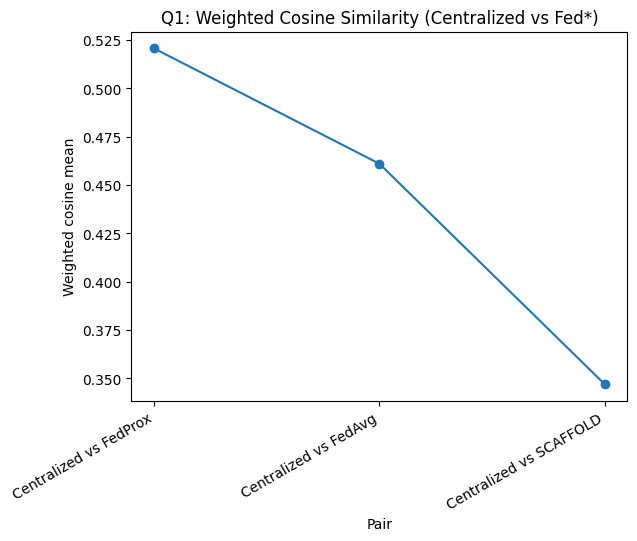

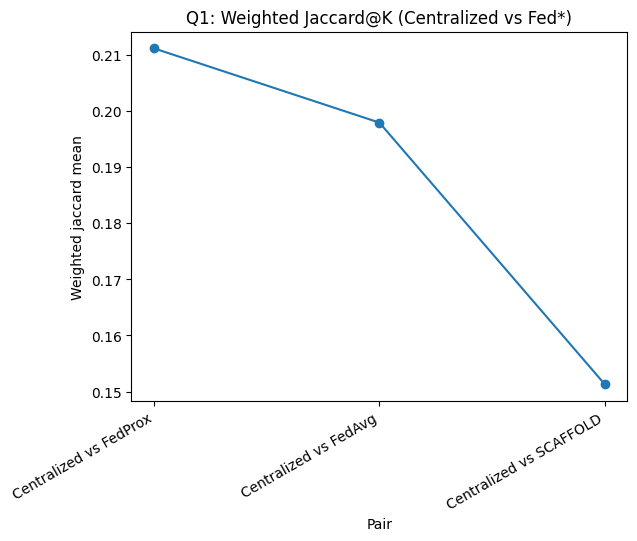

In [23]:
# Q1: (Optional) Quick plots for Centralized vs each federated method

# Filter pair summary to Centralized comparisons if present
central_pairs = q1_pair_summary[q1_pair_summary["pair"].str.startswith("Centralized") | q1_pair_summary["pair"].str.contains("Centralized")]

if len(central_pairs) == 0:
    print("No Centralized pairs found in summary (unexpected if Centralized model is loaded).")
else:
    plt.figure()
    plt.title("Q1: Weighted Cosine Similarity (Centralized vs Fed*)")
    plt.xlabel("Pair")
    plt.ylabel("Weighted cosine mean")
    plt.xticks(rotation=30, ha="right")
    plt.plot(central_pairs["pair"], central_pairs["cos_mean_weighted"], marker="o")
    plt.show()

    plt.figure()
    plt.title("Q1: Weighted Jaccard@K (Centralized vs Fed*)")
    plt.xlabel("Pair")
    plt.ylabel("Weighted jaccard mean")
    plt.xticks(rotation=30, ha="right")
    plt.plot(central_pairs["pair"], central_pairs["jac_mean_weighted"], marker="o")
    plt.show()


### Interpreting Q1 results (what to look for)

- High cosine + high Jaccard@K → models concentrate attention on similar token positions.
- High cosine but low Jaccard → attention mass is spread similarly but top tokens differ.
- Low cosine + low Jaccard → models rely on different parts of the sequence (different rationale patterns).

Always check `n_kept`:
- If `n_kept` is small for a label/pair, treat that label result as noisy.


### 2. Are there cases where models make the same prediction but rely on different tokens?

These cases are particularly important, as they indicate potential differences in learned clinical rationale even when accuracy agrees.

### 3. How does attention agreement change across label frequency?

We are especially interested in whether agreement degrades for rare diagnoses compared to frequent ones.

### 4. Which federated methods behave closest to centralized training in terms of attention structure?

This allows us to compare federated methods beyond predictive performance and look at behavioral alignment.